In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


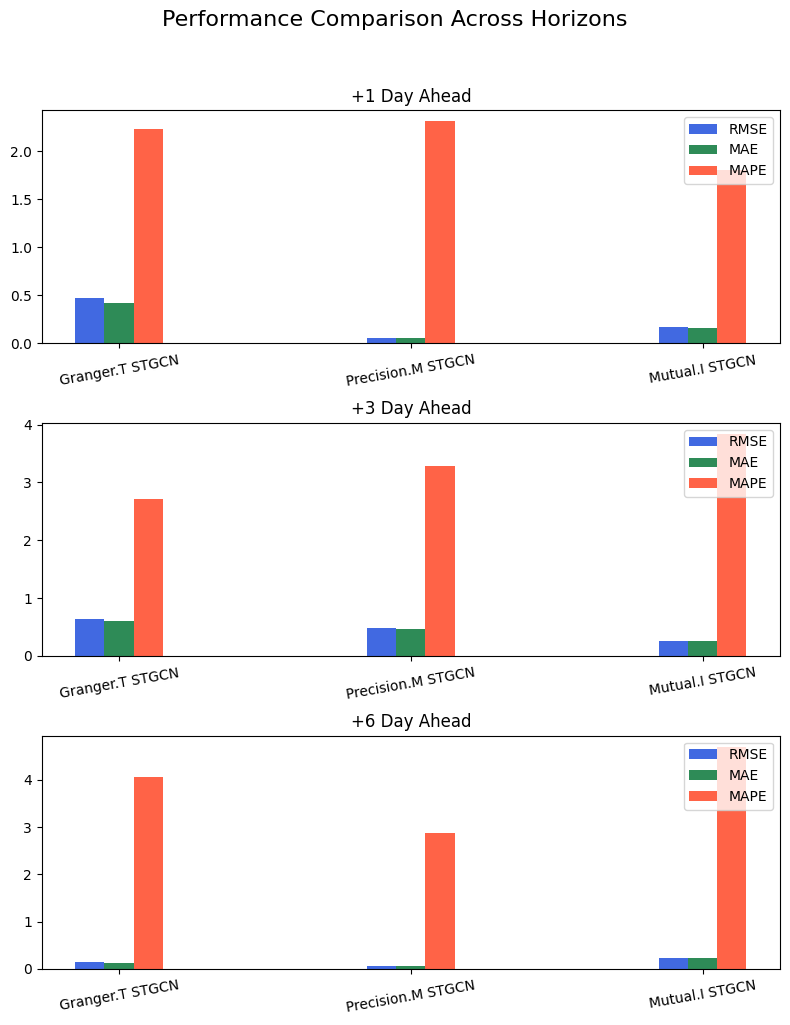

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load all CSVs ---
granger_df = pd.read_csv("/content/drive/MyDrive/Results/Grangernormeval.csv")
precision_df = pd.read_csv("/content/drive/MyDrive/Results/Precisionnormeval.csv")
mi_df = pd.read_csv("/content/drive/MyDrive/Results/Mutualnormeval.csv")

# --- Labels and horizon list ---
model_names = ['Granger.T STGCN', 'Precision.M STGCN', 'Mutual.I STGCN']
horizons = ['+1 Day', '+3 Day', '+6 Day']
metrics = ['Avg Normalized RMSE', 'Avg Normalized MAE', 'Avg MAPE']
colors = ['royalblue', 'seagreen', 'tomato']

# --- Collect values per horizon ---
def extract_metrics(df):
    return {
        'rmse': df[metrics[0]].values.tolist(),
        'mae': df[metrics[1]].values.tolist(),
        'mape': df[metrics[2]].values.tolist()
    }

granger_vals = extract_metrics(granger_df)
precision_vals = extract_metrics(precision_df)
mi_vals = extract_metrics(mi_df)

# Group data by horizon (0: +1 day, 1: +3 day, 2: +6 day)
all_data = [granger_vals, precision_vals, mi_vals]

# --- Plot ---
fig, axs = plt.subplots(3, 1, figsize=(8, 10))  # 3 charts vertically

for i, horizon in enumerate(horizons):
    rmse_vals = [d['rmse'][i] for d in all_data]
    mae_vals = [d['mae'][i] for d in all_data]
    mape_vals = [d['mape'][i] for d in all_data]

    bar_width = 0.1
    x = range(len(model_names))

    axs[i].bar([p - bar_width for p in x], rmse_vals, width=bar_width, label='RMSE', color=colors[0])
    axs[i].bar(x, mae_vals, width=bar_width, label='MAE', color=colors[1])
    axs[i].bar([p + bar_width for p in x], mape_vals, width=bar_width, label='MAPE', color=colors[2])

    axs[i].set_title(f"{horizon} Ahead", fontsize=12)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(model_names, rotation=10)
    #axs[i].set_ylabel("Metric Value")
    axs[i].legend(loc='upper right')

plt.tight_layout()
plt.suptitle("Performance Comparison Across Horizons", fontsize=16, y=1.02)
plt.subplots_adjust(top=0.92)
plt.show()


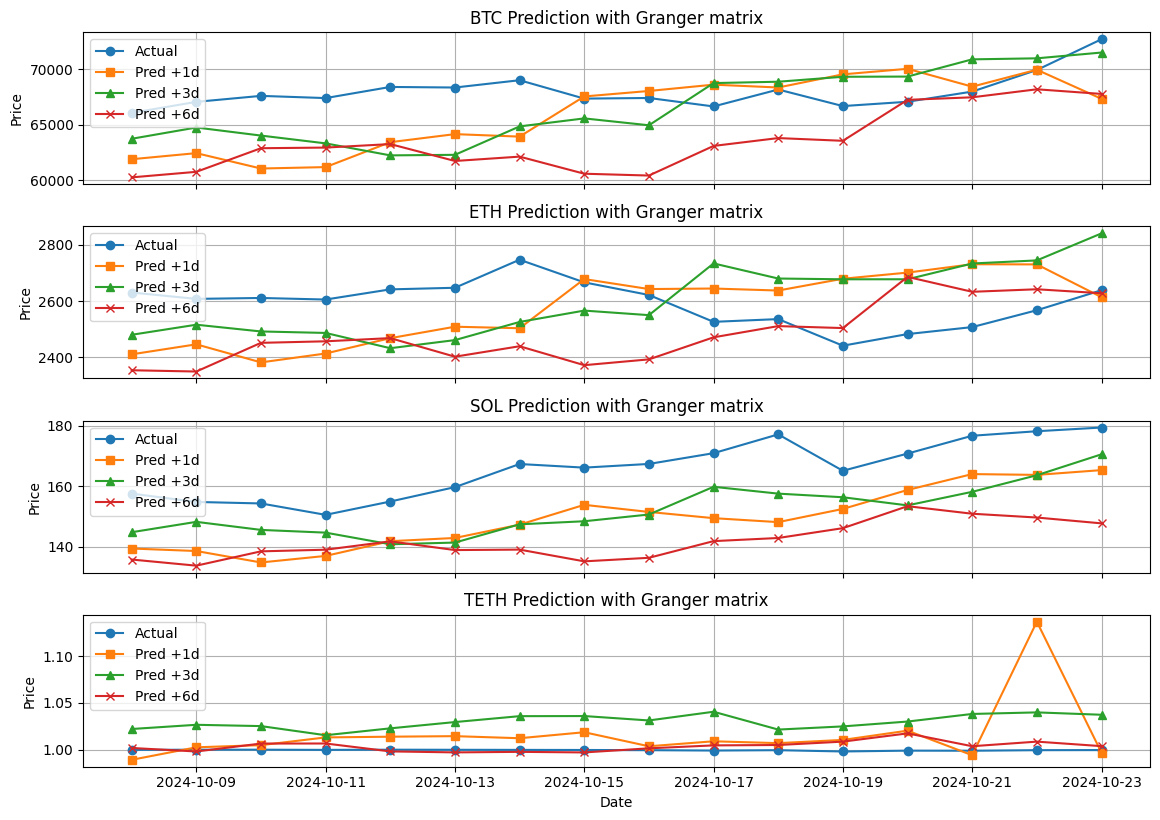

<Figure size 640x480 with 0 Axes>

In [6]:
# Define crypto names and path template
cryptos = ['btc', 'eth', 'sol', 'teth']
path_template = "/content/drive/MyDrive/Results/Granger/{}_linechart_data.csv"

# Set up a vertical layout of 4 subplots (one for each crypto)
#fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 18), sharex=True)

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(11.7, 8.3), sharex=True)#  To make it fit in A4 paper


for i, crypto in enumerate(cryptos):
    # Load CSV
    df = pd.read_csv(path_template.format(crypto))
    df['date'] = pd.to_datetime(df['date'])

    # Plot actual and predicted values
    axes[i].plot(df['date'], df['actual'], label='Actual', marker='o')
    axes[i].plot(df['date'], df['pred_T+1'], label='Pred +1d', marker='s')
    axes[i].plot(df['date'], df['pred_T+3'], label='Pred +3d', marker='^')
    axes[i].plot(df['date'], df['pred_T+6'], label='Pred +6d', marker='x')

    axes[i].set_title(f"{crypto.upper()} Prediction with Granger matrix")
    axes[i].set_ylabel("Price")
    axes[i].grid(True)
    axes[i].legend()

# Label shared x-axis
axes[-1].set_xlabel("Date")

# Improve spacing
plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/Results/Granger/crypto_linecharts_A4.png", dpi=300, bbox_inches='tight')# To save as an image to embed in my repot

